# Question 1: Speed of Light (Michelson's 1879 Experiment)

In [1]:
# (a) Load Michelson's 1879 dataset and state the hypothesis testing framework
import json
import numpy as np
import pandas as pd
from scipy import stats

# Load experiment determinations from the JSON file
with open('michelson_speed_of_light.json', 'r') as json_file:
    michelson_payload = json.load(json_file)

# Extract individual speed measurements (in km/s)
michelson_velocities = pd.Series(
    [entry['measured_speed_kmpersec'] for entry in michelson_payload['observations']],
    name='speed_km_s'
)

# Reference benchmark: true speed of light in air (km/s)
accepted_c_air = 299734.50
significance_alpha = 0.05

print(f"Null Hypothesis (H0): mu = {accepted_c_air:,.2f} km/s (Michelson's true mean measurement equals the accepted speed of light in air)")
print(f"Alternative Hypothesis (H1): mu != {accepted_c_air:,.2f} km/s (Michelson's true mean measurement systematically deviates from the accepted benchmark)")
print(f"Significance Level: alpha = {significance_alpha} (Two-tailed test)")
print(f"Sample Size (n): {len(michelson_velocities)} determinations")
print(f"Accepted Benchmark (mu_0): {accepted_c_air:,.2f} km/s")


Null Hypothesis (H0): mu = 299,734.50 km/s (Michelson's true mean measurement equals the accepted speed of light in air)
Alternative Hypothesis (H1): mu != 299,734.50 km/s (Michelson's true mean measurement systematically deviates from the accepted benchmark)
Significance Level: alpha = 0.05 (Two-tailed test)
Sample Size (n): 20 determinations
Accepted Benchmark (mu_0): 299,734.50 km/s


In [2]:
# (b) Assess normality of the sample using the Shapiro-Wilk test

# Perform the Shapiro-Wilk test on the 20 speed determinations
shapiro_w, shapiro_p = stats.shapiro(michelson_velocities)

print(f"Sample size (n): {len(michelson_velocities)} determinations")
print(f"Shapiro-Wilk test statistic (W): {shapiro_w:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
print(f"Significance threshold (alpha): {significance_alpha}")
print(f"Statistical Decision: {'Fail to Reject H0' if shapiro_p > significance_alpha else 'Reject H0'} (p = {shapiro_p:.4f} > 0.05)")
print("Conclusion: Normality assumption is statistically reasonable for parametric testing")


Sample size (n): 20 determinations
Shapiro-Wilk test statistic (W): 0.9199
Shapiro-Wilk p-value: 0.0988
Significance threshold (alpha): 0.05
Statistical Decision: Fail to Reject H0 (p = 0.0988 > 0.05)
Conclusion: Normality assumption is statistically reasonable for parametric testing


In [3]:
# (c) Conduct one-sample t-test against accepted speed of light in air

# Compute sample metrics
sample_count = len(michelson_velocities)
observed_mean = michelson_velocities.mean()
benchmark_mean = accepted_c_air
observed_sd = michelson_velocities.std(ddof=1)
standard_error = observed_sd / np.sqrt(sample_count)
degrees_of_freedom = sample_count - 1

# Execute one-sample t-test
t_statistic, two_tailed_p = stats.ttest_1samp(michelson_velocities, benchmark_mean)

# Display required statistical metrics
print(f"Sample size (n): {sample_count}")
print(f"Sample mean: {observed_mean:,.2f} km/s")
print(f"Population mean (accepted value): {benchmark_mean:,.2f} km/s")
print(f"Sample standard deviation: {observed_sd:,.2f} km/s")
print(f"Standard error of the mean (SEM): {standard_error:,.2f} km/s")
print(f"Degrees of freedom (df): {degrees_of_freedom}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {two_tailed_p:.4e}")
print(f"Reject H0 at alpha = {significance_alpha}: {two_tailed_p < significance_alpha}")

Sample size (n): 20
Sample mean: 299,909.00 km/s
Population mean (accepted value): 299,734.50 km/s
Sample standard deviation: 104.93 km/s
Standard error of the mean (SEM): 23.46 km/s
Degrees of freedom (df): 19
t-statistic: 7.4375
p-value: 4.8636e-07
Reject H0 at alpha = 0.05: True


In [4]:
# (d) Calculate bias and evaluate counterfactual scenario with n = 200

# 1. Bias calculations
measured_bias = observed_mean - benchmark_mean
percentage_bias = (measured_bias / benchmark_mean) * 100

print(f"Absolute bias: {measured_bias:+,.2f} km/s")
print(f"Percentage bias: {percentage_bias:+.4f}%")

# 2. Counterfactual recomputation with n = 200 (same mean and SD)
hypothetical_size = 200
scaled_sem = observed_sd / np.sqrt(hypothetical_size)
scaled_df = hypothetical_size - 1
scaled_t = measured_bias / scaled_sem
scaled_p = 2 * (1 - stats.t.cdf(abs(scaled_t), df=scaled_df))

print(f"Counterfactual SEM (n = {hypothetical_size}): {scaled_sem:,.2f} km/s")
print(f"Counterfactual df: {scaled_df}")
print(f"Counterfactual t-statistic: {scaled_t:.4f}")
print(f"Counterfactual p-value: {scaled_p:.4e}")

Absolute bias: +174.50 km/s
Percentage bias: +0.0582%
Counterfactual SEM (n = 200): 7.42 km/s
Counterfactual df: 199
Counterfactual t-statistic: 23.5194
Counterfactual p-value: 0.0000e+00


# Question 2: Chick Weights by Feed Type (Snedecor, 1948)

In [5]:
# (a) State hypothesis testing framework and justify test selection
feed_alpha = 0.05
print(f"Significance threshold (alpha): {feed_alpha}")

Significance threshold (alpha): 0.05


In [6]:
# (b) Load chick weight dataset and compute descriptive statistics per feed group

# Load data from CSV
poultry_df = pd.read_csv('chickwts_casein_soybean.csv')

# Separate into series for each diet
casein_group = poultry_df[poultry_df['feed'] == 'casein']['chick_weight_g']
soybean_group = poultry_df[poultry_df['feed'] == 'soybean']['chick_weight_g']

# Compute sample statistics for casein
n_casein = len(casein_group)
mean_casein = casein_group.mean()
sd_casein = casein_group.std(ddof=1)
var_casein = casein_group.var(ddof=1)

# Compute sample statistics for soybean
n_soybean = len(soybean_group)
mean_soybean = soybean_group.mean()
sd_soybean = soybean_group.std(ddof=1)
var_soybean = soybean_group.var(ddof=1)

# Display summary table
summary_stats = pd.DataFrame({
    'Sample Size (n)': [n_casein, n_soybean],
    'Mean (g)': [round(mean_casein, 2), round(mean_soybean, 2)],
    'Std Deviation (g)': [round(sd_casein, 2), round(sd_soybean, 2)],
    'Variance (g^2)': [round(var_casein, 2), round(var_soybean, 2)]
}, index=['Casein', 'Soybean'])

print(summary_stats.to_string())

         Sample Size (n)  Mean (g)  Std Deviation (g)  Variance (g^2)
Casein                12    323.58              64.43         4151.72
Soybean               14    246.43              54.13         2929.96


In [7]:
# (c) Carry out Welch's t-test

# Standard error of the difference in means
se_diff = np.sqrt((var_casein / n_casein) + (var_soybean / n_soybean))

# Welch-Satterthwaite degrees of freedom
welch_df_numerator = ((var_casein / n_casein) + (var_soybean / n_soybean)) ** 2
welch_df_denominator = (((var_casein / n_casein) ** 2) / (n_casein - 1)) + (((var_soybean / n_soybean) ** 2) / (n_soybean - 1))
welch_degrees_freedom = welch_df_numerator / welch_df_denominator

# Welch t-test via scipy (equal_var=False specifies Welch's correction)
welch_t_stat, welch_p_val = stats.ttest_ind(casein_group, soybean_group, equal_var=False)

print(f"Difference in means (Casein - Soybean): {mean_casein - mean_soybean:,.2f} g")
print(f"Standard error of difference: {se_diff:,.2f} g")
print(f"Welch degrees of freedom: {welch_degrees_freedom:.2f}")
print(f"Welch t-statistic: {welch_t_stat:.4f}")
print(f"p-value: {welch_p_val:.4f}")
print(f"Reject H0 at alpha = {feed_alpha}: {welch_p_val < feed_alpha}")

Difference in means (Casein - Soybean): 77.15 g
Standard error of difference: 23.56 g
Welch degrees of freedom: 21.63
Welch t-statistic: 3.2743
p-value: 0.0035
Reject H0 at alpha = 0.05: True


In [8]:
# (d) Evaluate effect size and practical/agricultural importance

weight_diff_g = mean_casein - mean_soybean
pct_gain = (weight_diff_g / mean_soybean) * 100

# Pooled standard deviation for Cohen's d effect size
pooled_sd = np.sqrt(((n_casein - 1) * var_casein + (n_soybean - 1) * var_soybean) / (n_casein + n_soybean - 2))
cohens_d = weight_diff_g / pooled_sd

print(f"Mean weight difference: {weight_diff_g:,.2f} g")
print(f"Percentage difference: {pct_gain:.1f}%")
print(f"Cohen's d: {cohens_d:.2f}")

Mean weight difference: 77.15 g
Percentage difference: 31.3%
Cohen's d: 1.31


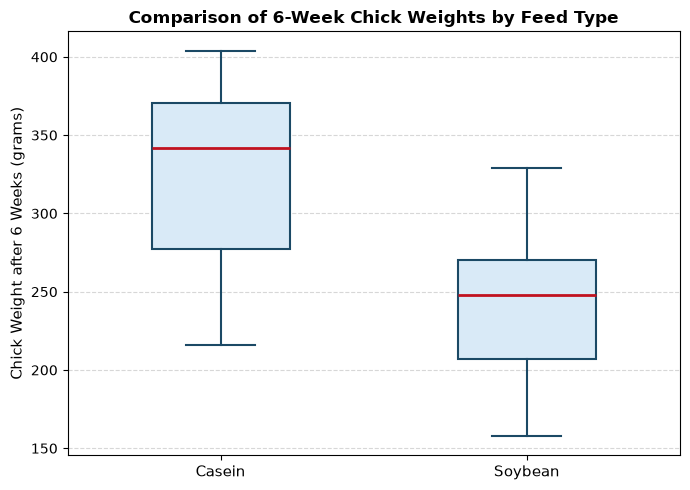

In [9]:
# (e) Generate side-by-side boxplot comparing chick weights by feed type
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Plot boxplot without version-dependent keyword arguments
plt.boxplot(
    [casein_group, soybean_group],
    patch_artist=True,
    widths=0.45,
    boxprops=dict(facecolor='#d9eaf7', color='#1b4965', linewidth=1.5),
    medianprops=dict(color='#c1121f', linewidth=2.0),
    whiskerprops=dict(color='#1b4965', linewidth=1.5),
    capprops=dict(color='#1b4965', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#e63946', markersize=6, linestyle='none')
)

# Set category tick labels directly (universal across all Matplotlib versions)
plt.xticks([1, 2], ['Casein', 'Soybean'], fontsize=11)
plt.ylabel('Chick Weight after 6 Weeks (grams)', fontsize=11)
plt.title('Comparison of 6-Week Chick Weights by Feed Type', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Question 3: Fertility Rate vs. GDP per Capita (World Bank 2024)

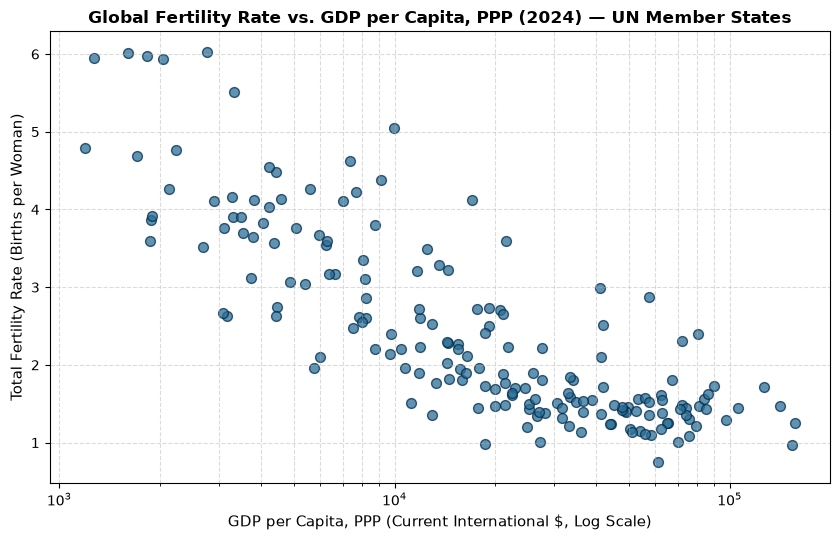

UN Member States with complete 2024 data: 183


In [10]:
# (a) Load 2024 World Bank data via API for UN Member States and plot Fertility Rate vs. GDP per Capita (PPP)
import json
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# 1. Official 193 United Nations Member States (ISO-3 codes)
# Source: United Nations Member States (https://www.un.org/en/about-us/member-states)
un_member_codes = {
    'AFG', 'ALB', 'DZA', 'AND', 'AGO', 'ATG', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE',
    'BHS', 'BHR', 'BGD', 'BRB', 'BLR', 'BEL', 'BLZ', 'BEN', 'BTN', 'BOL', 'BIH',
    'BWA', 'BRA', 'BRN', 'BGR', 'BFA', 'BDI', 'CPV', 'KHM', 'CMR', 'CAN', 'CAF',
    'TCD', 'CHL', 'CHN', 'COL', 'COM', 'COG', 'COD', 'CRI', 'CIV', 'HRV', 'CUB',
    'CYP', 'CZE', 'PRK', 'DNK', 'DJI', 'DMA', 'DOM', 'ECU', 'EGY', 'SLV', 'GNQ',
    'ERI', 'EST', 'SWZ', 'ETH', 'FJI', 'FIN', 'FRA', 'GAB', 'GMB', 'GEO', 'DEU',
    'GHA', 'GRC', 'GRD', 'GTM', 'GIN', 'GNB', 'GUY', 'HTI', 'HND', 'HUN', 'ISL',
    'IND', 'IDN', 'IRN', 'IRQ', 'IRL', 'ISR', 'ITA', 'JAM', 'JPN', 'JOR', 'KAZ',
    'KEN', 'KIR', 'KWT', 'KGZ', 'LAO', 'LVA', 'LBN', 'LSO', 'LBR', 'LBY', 'LIE',
    'LTU', 'LUX', 'MDG', 'MWI', 'MYS', 'MDV', 'MLI', 'MLT', 'MHL', 'MRT', 'MUS',
    'MEX', 'FSM', 'MDA', 'MCO', 'MNG', 'MNE', 'MAR', 'MOZ', 'MMR', 'NAM', 'NRU',
    'NPL', 'NLD', 'NZL', 'NIC', 'NER', 'NGA', 'MKD', 'NOR', 'OMN', 'PAK', 'PLW',
    'PAN', 'PNG', 'PRY', 'PER', 'PHL', 'POL', 'PRT', 'QAT', 'KOR', 'ROU', 'RUS',
    'RWA', 'KNA', 'LCA', 'VCT', 'WSM', 'SMR', 'STP', 'SAU', 'SEN', 'SRB', 'SYC',
    'SLE', 'SGP', 'SVK', 'SVN', 'SLB', 'SOM', 'ZAF', 'SSD', 'ESP', 'LKA', 'SDN',
    'SUR', 'SWE', 'CHE', 'SYR', 'TJK', 'THA', 'TLS', 'TGO', 'TON', 'TTO', 'TUN',
    'TUR', 'TKM', 'TUV', 'UGA', 'UKR', 'ARE', 'GBR', 'TZA', 'USA', 'URY', 'UZB',
    'VUT', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE'
}

assert len(un_member_codes) == 193, 'The UN Member State set must contain 193 codes.'

# 2. Fetch indicators from World Bank API for 2024
def fetch_world_bank_data(indicator_id):
    api_url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_id}?date=2024&format=json&per_page=300"
    request = urllib.request.Request(api_url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(request) as response:
        content = json.loads(response.read().decode('utf-8'))[1]
    return {
        item['countryiso3code']: (item['country']['value'], item['value'])
        for item in content if item.get('countryiso3code')
    }

# Fetch Total Fertility Rate (SP.DYN.TFRT.IN) and GDP per Capita PPP (NY.GDP.PCAP.PP.CD)
fertility_lookup = fetch_world_bank_data('SP.DYN.TFRT.IN')
gdp_ppp_lookup = fetch_world_bank_data('NY.GDP.PCAP.PP.CD')

# 3. Build clean DataFrame restricted to UN Member States
country_records = []
for code in sorted(un_member_codes):
    country_name = fertility_lookup.get(code, (code, None))[0]
    fertility_val = fertility_lookup.get(code, (None, None))[1]
    gdp_val = gdp_ppp_lookup.get(code, (None, None))[1]
    country_records.append({
        'country_code': code,
        'country_name': country_name,
        'fertility_rate': fertility_val,
        'gdp_per_capita_ppp': gdp_val
    })

wb_demographics = pd.DataFrame(country_records).dropna(subset=['fertility_rate', 'gdp_per_capita_ppp']).reset_index(drop=True)

# 4. Produce carefully labeled scatter plot with logarithmic x-axis
plt.figure(figsize=(8.5, 5.5))
plt.scatter(
    wb_demographics['gdp_per_capita_ppp'],
    wb_demographics['fertility_rate'],
    color='#2a6f97',
    edgecolor='#012a4a',
    alpha=0.75,
    s=50
)

plt.xscale('log')
plt.xlabel('GDP per Capita, PPP (Current International $, Log Scale)', fontsize=11)
plt.ylabel('Total Fertility Rate (Births per Woman)', fontsize=11)
plt.title('Global Fertility Rate vs. GDP per Capita, PPP (2024) — UN Member States', fontsize=12, fontweight='bold')
plt.grid(True, which='both', linestyle='--', alpha=0.45)
plt.tight_layout()
plt.show()

# Display summary count
print(f"UN Member States with complete 2024 data: {len(wb_demographics)}")

In [11]:
# (b) Estimate Pearson (raw and log GDP) and Spearman correlations

# 1. Natural log transform of GDP per capita
wb_demographics['log_gdp_per_capita_ppp'] = np.log(wb_demographics['gdp_per_capita_ppp'])

# 2. Pearson correlation on raw GDP
pearson_raw_r, pearson_raw_p = stats.pearsonr(
    wb_demographics['fertility_rate'],
    wb_demographics['gdp_per_capita_ppp']
)

# 3. Pearson correlation on log(GDP)
pearson_log_r, pearson_log_p = stats.pearsonr(
    wb_demographics['fertility_rate'],
    wb_demographics['log_gdp_per_capita_ppp']
)

# 4. Spearman rank correlation on raw GDP
spearman_rho, spearman_p = stats.spearmanr(
    wb_demographics['fertility_rate'],
    wb_demographics['gdp_per_capita_ppp']
)

# Display strictly the computed numerical coefficients
print(f"Pearson (Raw GDP):       r = {pearson_raw_r:.4f}  (p = {pearson_raw_p:.4e})")
print(f"Pearson (log GDP):       r = {pearson_log_r:.4f}  (p = {pearson_log_p:.4e})")
print(f"Spearman Rank (Raw GDP): rho = {spearman_rho:.4f}  (p = {spearman_p:.4e})")

Pearson (Raw GDP):       r = -0.6004  (p = 2.6482e-19)
Pearson (log GDP):       r = -0.8223  (p = 3.4799e-46)
Spearman Rank (Raw GDP): rho = -0.8206  (p = 7.5708e-46)


In [12]:
# (c) Identify extreme observations (|z| > 2.5) and recompute correlations

# 1. Compute z-scores for fertility rate and log GDP per capita
wb_demographics['z_fertility'] = stats.zscore(wb_demographics['fertility_rate'])
wb_demographics['z_log_gdp'] = stats.zscore(wb_demographics['log_gdp_per_capita_ppp'])

# 2. Filter countries where |z| > 2.5 on fertility OR log GDP
outlier_mask = (wb_demographics['z_fertility'].abs() > 2.5) | (wb_demographics['z_log_gdp'].abs() > 2.5)
outlier_countries = wb_demographics[outlier_mask].copy()

print(f"Extreme observations identified (|z| > 2.5): {len(outlier_countries)}")
print(outlier_countries[['country_code', 'country_name', 'fertility_rate', 'gdp_per_capita_ppp', 'z_fertility', 'z_log_gdp']].to_string(index=False))

# 3. Create trimmed dataset excluding extreme observations
trimmed_demographics = wb_demographics[~outlier_mask].copy()

# 4. Recompute correlations on trimmed data
trim_pearson_raw_r, trim_pearson_raw_p = stats.pearsonr(
    trimmed_demographics['fertility_rate'],
    trimmed_demographics['gdp_per_capita_ppp']
)

trim_pearson_log_r, trim_pearson_log_p = stats.pearsonr(
    trimmed_demographics['fertility_rate'],
    trimmed_demographics['log_gdp_per_capita_ppp']
)

trim_spearman_rho, trim_spearman_p = stats.spearmanr(
    trimmed_demographics['fertility_rate'],
    trimmed_demographics['gdp_per_capita_ppp']
)

print(f"\nTrimmed sample size: {len(trimmed_demographics)}")
print(f"Trimmed Pearson (Raw GDP):       r = {trim_pearson_raw_r:.4f}  (p = {trim_pearson_raw_p:.4e})")
print(f"Trimmed Pearson (log GDP):       r = {trim_pearson_log_r:.4f}  (p = {trim_pearson_log_p:.4e})")
print(f"Trimmed Spearman Rank (Raw GDP): rho = {trim_spearman_rho:.4f}  (p = {trim_spearman_p:.4e})")

Extreme observations identified (|z| > 2.5): 6
country_code             country_name  fertility_rate  gdp_per_capita_ppp  z_fertility  z_log_gdp
         CAF Central African Republic           5.954         1264.936717     2.902948  -2.256149
         COD         Congo, Dem. Rep.           5.981         1823.277051     2.925148  -1.939068
         MLI                     Mali           5.510         3321.576144     2.537887  -1.418883
         NER                    Niger           5.935         2044.049049     2.887326  -1.839943
         SOM       Somalia, Fed. Rep.           6.013         1604.291163     2.951458  -2.050037
         TCD                     Chad           6.028         2766.981349     2.963791  -1.577316

Trimmed sample size: 177
Trimmed Pearson (Raw GDP):       r = -0.6101  (p = 1.9830e-19)
Trimmed Pearson (log GDP):       r = -0.8051  (p = 1.4684e-41)
Trimmed Spearman Rank (Raw GDP): rho = -0.8030  (p = 3.4398e-41)


# Question 4: UK House Price Index Time Series Analysis (Nationwide)

c:\Users\hp\Desktop\DIML\nalain\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: Monthly!$A:$F.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


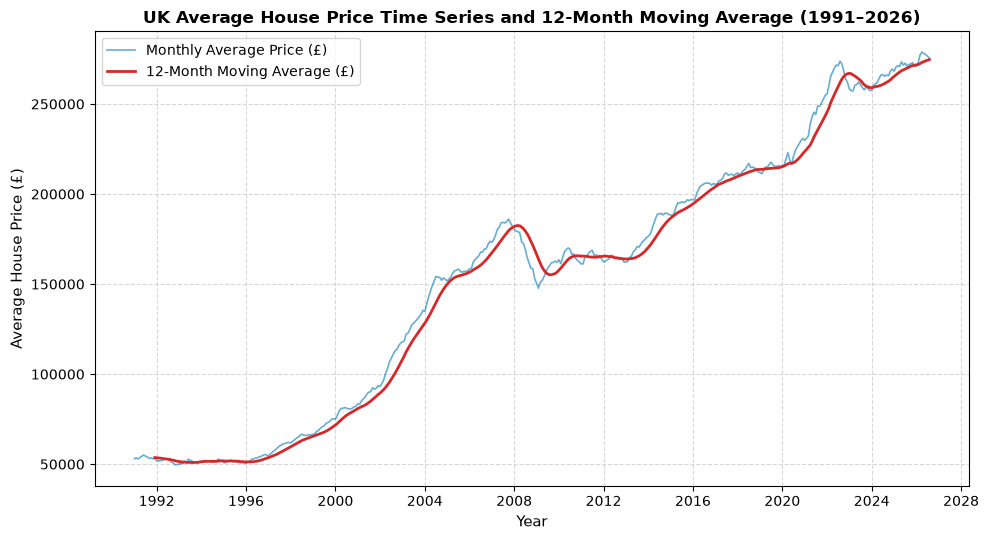

Time series span: Jan 1991 to Aug 2026
Total observations: 428 months
Starting price (Jan 1991): £53,051.72
Ending price (Aug 2026):   £275,465.06


In [13]:
# (a) Load UK monthly house price series and overlay 12-month moving average
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data from Excel (Sheet 'Monthly')
uk_housing_raw = pd.read_excel('Monthly.xlsx', sheet_name='Monthly')

# Extract Date and Average House Price columns
uk_housing_df = uk_housing_raw.iloc[:, [0, 1]].dropna().copy()
uk_housing_df.columns = ['date', 'average_price']
uk_housing_df['date'] = pd.to_datetime(uk_housing_df['date'])
uk_housing_df = uk_housing_df.sort_values('date').reset_index(drop=True)

# 2. Calculate 12-month rolling moving average
uk_housing_df['ma_12_month'] = uk_housing_df['average_price'].rolling(window=12).mean()

# 3. Time series plot with moving average overlay
plt.figure(figsize=(10, 5.5))
plt.plot(uk_housing_df['date'], uk_housing_df['average_price'], label='Monthly Average Price (£)', color='#0077b6', alpha=0.6, linewidth=1.2)
plt.plot(uk_housing_df['date'], uk_housing_df['ma_12_month'], label='12-Month Moving Average (£)', color='#d62828', linewidth=2.0)

plt.xlabel('Year', fontsize=11)
plt.ylabel('Average House Price (£)', fontsize=11)
plt.title('UK Average House Price Time Series and 12-Month Moving Average (1991–2026)', fontsize=12, fontweight='bold')
plt.legend(frameon=True, facecolor='white', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display summary range
print(f"Time series span: {uk_housing_df['date'].min().strftime('%b %Y')} to {uk_housing_df['date'].max().strftime('%b %Y')}")
print(f"Total observations: {len(uk_housing_df)} months")
print(f"Starting price ({uk_housing_df['date'].min().strftime('%b %Y')}): £{uk_housing_df['average_price'].iloc[0]:,.2f}")
print(f"Ending price ({uk_housing_df['date'].max().strftime('%b %Y')}):   £{uk_housing_df['average_price'].iloc[-1]:,.2f}")

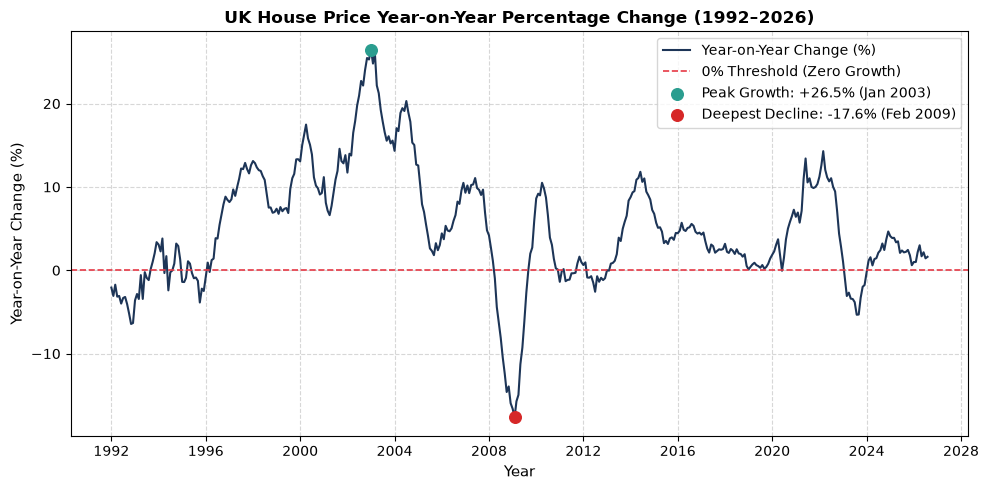

Sharpest YoY Growth:  +26.47% (Jan 2003)
Sharpest YoY Decline: -17.63% (Feb 2009)


In [14]:
# (b) Calculate Year-on-Year (YoY) percentage change, plot series, and identify extremes

# 1. Compute 12-month YoY percentage change
uk_housing_df['yoy_percentage_change'] = uk_housing_df['average_price'].pct_change(periods=12) * 100

# 2. Identify peak growth and deepest decline
max_growth_idx = uk_housing_df['yoy_percentage_change'].idxmax()
min_decline_idx = uk_housing_df['yoy_percentage_change'].idxmin()

peak_growth_date = uk_housing_df.loc[max_growth_idx, 'date'].strftime('%b %Y')
peak_growth_val = uk_housing_df.loc[max_growth_idx, 'yoy_percentage_change']

trough_decline_date = uk_housing_df.loc[min_decline_idx, 'date'].strftime('%b %Y')
trough_decline_val = uk_housing_df.loc[min_decline_idx, 'yoy_percentage_change']

# 3. Time series plot of YoY change with 0% reference line
plt.figure(figsize=(10, 5))
plt.plot(uk_housing_df['date'], uk_housing_df['yoy_percentage_change'], color='#1d3557', linewidth=1.5, label='Year-on-Year Change (%)')
plt.axhline(0, color='#e63946', linestyle='--', linewidth=1.2, label='0% Threshold (Zero Growth)')

# Mark the two extreme points on the graph
plt.scatter(uk_housing_df.loc[max_growth_idx, 'date'], peak_growth_val, color='#2a9d8f', s=70, zorder=5, label=f'Peak Growth: +{peak_growth_val:.1f}% ({peak_growth_date})')
plt.scatter(uk_housing_df.loc[min_decline_idx, 'date'], trough_decline_val, color='#d62828', s=70, zorder=5, label=f'Deepest Decline: {trough_decline_val:.1f}% ({trough_decline_date})')

plt.xlabel('Year', fontsize=11)
plt.ylabel('Year-on-Year Change (%)', fontsize=11)
plt.title('UK House Price Year-on-Year Percentage Change (1992–2026)', fontsize=12, fontweight='bold')
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display strictly the computed extreme values
print(f"Sharpest YoY Growth:  +{peak_growth_val:.2f}% ({peak_growth_date})")
print(f"Sharpest YoY Decline: {trough_decline_val:.2f}% ({trough_decline_date})")

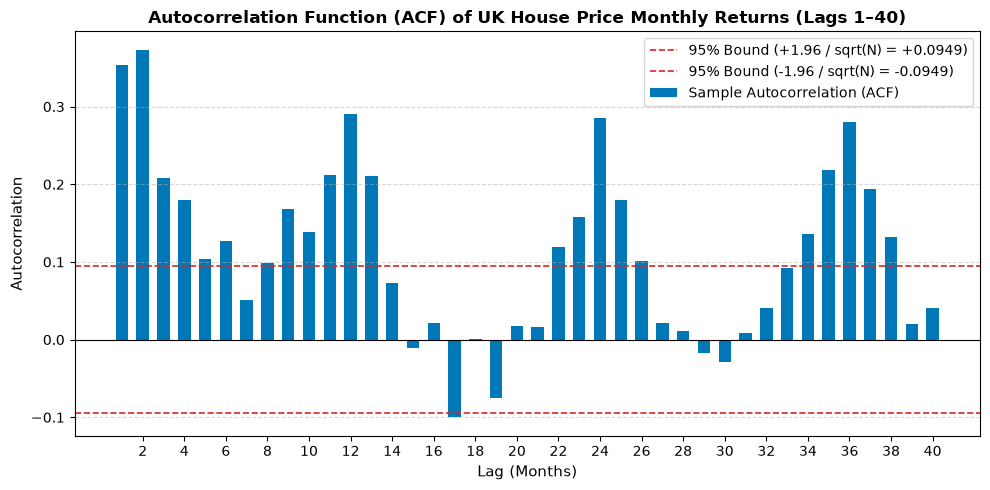

Total return observations (N): 427
95% significance threshold (+/- 1.96 / sqrt(N)): +/- 0.0949
Lag 1 Autocorrelation: 0.3532 (Significant: True)
Lag 2 Autocorrelation: 0.3733 (Significant: True)
Lag 12 Autocorrelation: 0.2901 (Significant: True)


In [15]:
# (c) Construct monthly returns, plot ACF for lags 1 to 40 with 95% significance bounds

# 1. Compute monthly returns: r(t) = [p(t) / p(t-1)] - 1
uk_housing_df['monthly_return'] = uk_housing_df['average_price'].pct_change()
returns_series = uk_housing_df['monthly_return'].dropna().reset_index(drop=True)

# 2. Number of observations and Bartlett 95% significance bound (alpha = 0.05)
n_returns = len(returns_series)
significance_threshold = 1.96 / np.sqrt(n_returns)

# 3. Compute sample autocorrelation for lags 1 through 40
lags = list(range(1, 41))
acf_values = [returns_series.autocorr(lag=k) for k in lags]

# 4. Plot ACF as a bar graph
plt.figure(figsize=(10, 5))
plt.bar(lags, acf_values, color='#0077b6', width=0.6, label='Sample Autocorrelation (ACF)')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(significance_threshold, color='#d62828', linestyle='--', linewidth=1.2, label=f'95% Bound (+1.96 / sqrt(N) = +{significance_threshold:.4f})')
plt.axhline(-significance_threshold, color='#d62828', linestyle='--', linewidth=1.2, label=f'95% Bound (-1.96 / sqrt(N) = -{significance_threshold:.4f})')

plt.xlabel('Lag (Months)', fontsize=11)
plt.ylabel('Autocorrelation', fontsize=11)
plt.title('Autocorrelation Function (ACF) of UK House Price Monthly Returns (Lags 1–40)', fontsize=12, fontweight='bold')
plt.xticks(range(2, 41, 2))
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display strictly the computed metrics
print(f"Total return observations (N): {n_returns}")
print(f"95% significance threshold (+/- 1.96 / sqrt(N)): +/- {significance_threshold:.4f}")
print(f"Lag 1 Autocorrelation: {acf_values[0]:.4f} (Significant: {abs(acf_values[0]) > significance_threshold})")
print(f"Lag 2 Autocorrelation: {acf_values[1]:.4f} (Significant: {abs(acf_values[1]) > significance_threshold})")
print(f"Lag 12 Autocorrelation: {acf_values[11]:.4f} (Significant: {abs(acf_values[11]) > significance_threshold})")

In [16]:
# (d) Calculate Compound Annual Growth Rate (CAGR) across the three historical periods

# Helper function to compute CAGR
def compute_cagr(start_price, end_price, months):
    years = months / 12.0
    return ((end_price / start_price) ** (1.0 / years) - 1.0) * 100

# 1. Full Dataset: Jan 1991 to Aug 2026
months_full = len(uk_housing_df) - 1
cagr_full = compute_cagr(uk_housing_df['average_price'].iloc[0], uk_housing_df['average_price'].iloc[-1], months_full)

# 2. Pre-2008: Jan 1991 to Dec 2007
df_pre_2008 = uk_housing_df[uk_housing_df['date'] <= '2007-12-01']
months_pre = len(df_pre_2008) - 1
cagr_pre = compute_cagr(df_pre_2008['average_price'].iloc[0], df_pre_2008['average_price'].iloc[-1], months_pre)

# 3. Post-2008: Dec 2007 to Aug 2026
df_post_2008 = uk_housing_df[uk_housing_df['date'] >= '2007-12-01']
months_post = len(df_post_2008) - 1
cagr_post = compute_cagr(df_post_2008['average_price'].iloc[0], df_post_2008['average_price'].iloc[-1], months_post)

# Display strictly the computed CAGR figures
print(f"Full Dataset CAGR (1991–2026, {months_full/12:.2f} yrs): {cagr_full:.2f}% per year")
print(f"Pre-2008 CAGR     (1991–2007, {months_pre/12:.2f} yrs): {cagr_pre:.2f}% per year")
print(f"Post-2008 CAGR    (2007–2026, {months_post/12:.2f} yrs): {cagr_post:.2f}% per year")

Full Dataset CAGR (1991–2026, 35.58 yrs): 4.74% per year
Pre-2008 CAGR     (1991–2007, 16.92 yrs): 7.56% per year
Post-2008 CAGR    (2007–2026, 18.67 yrs): 2.24% per year


# Question 5: UK House Prices vs. FTSE 100 Index (1991–2026)

c:\Users\hp\Desktop\DIML\nalain\.venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: Monthly!$A:$F.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


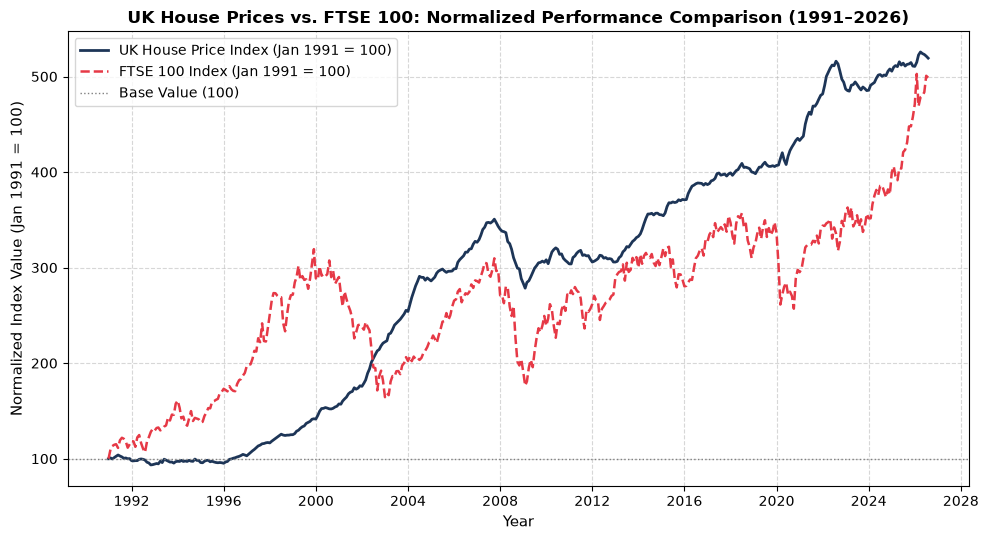

Sample span: Jan 1991 to Aug 2026 (428 months)
Base UK House Price (Jan 1991): £53,051.72 -> Base Index: 100.00
Base FTSE 100 Price (Jan 1991):  2,170.30 -> Base Index: 100.00
Terminal UK House Price Index (Aug 2026): 519.24
Terminal FTSE 100 Index        (Aug 2026): 498.75


In [17]:
# (a) Merge datasets, normalize both series to 100 at Jan 1991, and plot dual time series
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and align datasets
uk_housing_clean = pd.read_excel('Monthly.xlsx', sheet_name='Monthly').iloc[:, [0, 1]].dropna().copy()
uk_housing_clean.columns = ['date', 'house_price']
uk_housing_clean['date'] = pd.to_datetime(uk_housing_clean['date'])

ftse_clean = pd.read_csv('FTSE100.csv')
ftse_clean['date'] = pd.to_datetime(ftse_clean['Date'])
ftse_clean = ftse_clean[['date', 'Close']].rename(columns={'Close': 'ftse_price'})

merged_market_df = pd.merge(uk_housing_clean, ftse_clean, on='date', how='inner').sort_values('date').reset_index(drop=True)

# 2. Normalize both series to 100 at base date (January 1991 = 100)
base_house_price = merged_market_df['house_price'].iloc[0]
base_ftse_price = merged_market_df['ftse_price'].iloc[0]

merged_market_df['house_norm'] = (merged_market_df['house_price'] / base_house_price) * 100
merged_market_df['ftse_norm'] = (merged_market_df['ftse_price'] / base_ftse_price) * 100

# 3. Dual time series plot
plt.figure(figsize=(10, 5.5))
plt.plot(merged_market_df['date'], merged_market_df['house_norm'], label='UK House Price Index (Jan 1991 = 100)', color='#1d3557', linewidth=2.0)
plt.plot(merged_market_df['date'], merged_market_df['ftse_norm'], label='FTSE 100 Index (Jan 1991 = 100)', color='#e63946', linewidth=1.8, linestyle='--')
plt.axhline(100, color='gray', linestyle=':', linewidth=1.0, label='Base Value (100)')

plt.xlabel('Year', fontsize=11)
plt.ylabel('Normalized Index Value (Jan 1991 = 100)', fontsize=11)
plt.title('UK House Prices vs. FTSE 100: Normalized Performance Comparison (1991–2026)', fontsize=12, fontweight='bold')
plt.legend(frameon=True, facecolor='white', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display strictly the computed normalized terminal values
print(f"Sample span: {merged_market_df['date'].iloc[0].strftime('%b %Y')} to {merged_market_df['date'].iloc[-1].strftime('%b %Y')} ({len(merged_market_df)} months)")
print(f"Base UK House Price (Jan 1991): £{base_house_price:,.2f} -> Base Index: 100.00")
print(f"Base FTSE 100 Price (Jan 1991):  {base_ftse_price:,.2f} -> Base Index: 100.00")
print(f"Terminal UK House Price Index (Aug 2026): {merged_market_df['house_norm'].iloc[-1]:.2f}")
print(f"Terminal FTSE 100 Index        (Aug 2026): {merged_market_df['ftse_norm'].iloc[-1]:.2f}")


In [18]:
# (b) Compute Compound Annual Growth Rate (Geometric CAGR) and Annualized Arithmetic Mean

# Calculate monthly percentage returns
merged_market_df['house_ret'] = merged_market_df['house_price'].pct_change()
merged_market_df['ftse_ret'] = merged_market_df['ftse_price'].pct_change()

n_holding_months = len(merged_market_df) - 1
elapsed_years = n_holding_months / 12.0

# 1. Geometric Compound Annual Growth Rate (CAGR)
cagr_house = ((merged_market_df['house_price'].iloc[-1] / merged_market_df['house_price'].iloc[0]) ** (1.0 / elapsed_years) - 1.0) * 100
cagr_ftse = ((merged_market_df['ftse_price'].iloc[-1] / merged_market_df['ftse_price'].iloc[0]) ** (1.0 / elapsed_years) - 1.0) * 100

# 2. Annualized Arithmetic Mean Return
arith_house = merged_market_df['house_ret'].mean() * 12.0 * 100
arith_ftse = merged_market_df['ftse_ret'].mean() * 12.0 * 100

# Display strictly computed metrics
print(f"Total investment period: {elapsed_years:.2f} years ({n_holding_months} monthly intervals)")
print(f"UK House Prices - Geometric CAGR:          {cagr_house:.2f}% per year")
print(f"UK House Prices - Annualized Arithmetic:   {arith_house:.2f}% per year")
print(f"FTSE 100 Index  - Geometric CAGR:          {cagr_ftse:.2f}% per year")
print(f"FTSE 100 Index  - Annualized Arithmetic:   {arith_ftse:.2f}% per year")


Total investment period: 35.58 years (427 monthly intervals)
UK House Prices - Geometric CAGR:          4.74% per year
UK House Prices - Annualized Arithmetic:   4.71% per year
FTSE 100 Index  - Geometric CAGR:          4.62% per year
FTSE 100 Index  - Annualized Arithmetic:   5.43% per year


In [19]:



# (c) Compute annualized volatility of monthly returns using the sqrt(12) scaling factor

# Sample standard deviation of monthly returns (Bessel's correction ddof=1)
monthly_sd_house = merged_market_df['house_ret'].std(ddof=1)
monthly_sd_ftse = merged_market_df['ftse_ret'].std(ddof=1)

# Annualized volatility: sigma_annual = s_monthly * sqrt(12)
annual_vol_house = monthly_sd_house * np.sqrt(12) * 100
annual_vol_ftse = monthly_sd_ftse * np.sqrt(12) * 100

# Display strictly computed volatility metrics
print(f"UK House Prices - Monthly Return SD:  {monthly_sd_house * 100:.2f}% ")
print(f"UK House Prices - Annualized Vol:     {annual_vol_house:.2f}%")
print(f"FTSE 100 Index  - Monthly Return SD:  {monthly_sd_ftse * 100:.2f}%")
print(f"FTSE 100 Index  - Annualized Vol:     {annual_vol_ftse:.2f}%")
print(f"Volatility Ratio (FTSE 100 / Houses): {annual_vol_ftse / annual_vol_house:.2f}x")

UK House Prices - Monthly Return SD:  1.06% 
UK House Prices - Annualized Vol:     3.67%
FTSE 100 Index  - Monthly Return SD:  3.86%
FTSE 100 Index  - Annualized Vol:     13.38%
Volatility Ratio (FTSE 100 / Houses): 3.65x
